Regions used for clustering: 7
['East Midlands', 'London', 'North East', 'North West', 'South East', 'South West', 'West Midlands']


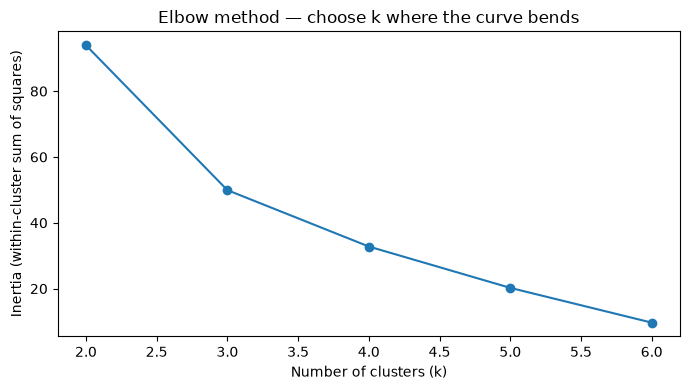

Elbow plot saved to elbow_plot.png

K-Means (K=3) — Region assignments:
       Region  Cluster  Pay_Resident  Pay_Workplace  Pay_Diff_Pct  Rental_Index
   North West        0       38209.6        38178.4     -0.081655         122.7
   North East        0       35989.2        35422.4     -1.574917         115.9
   South West        0       38168.0        37892.4     -0.722071         129.2
       London        1       46940.4        49826.4      6.148222         121.2
East Midlands        2       37481.6        36597.6     -2.358491         132.8
   South East        2       42390.4        40341.6     -4.833170         127.0
West Midlands        2       38012.0        37980.8     -0.082079         126.7


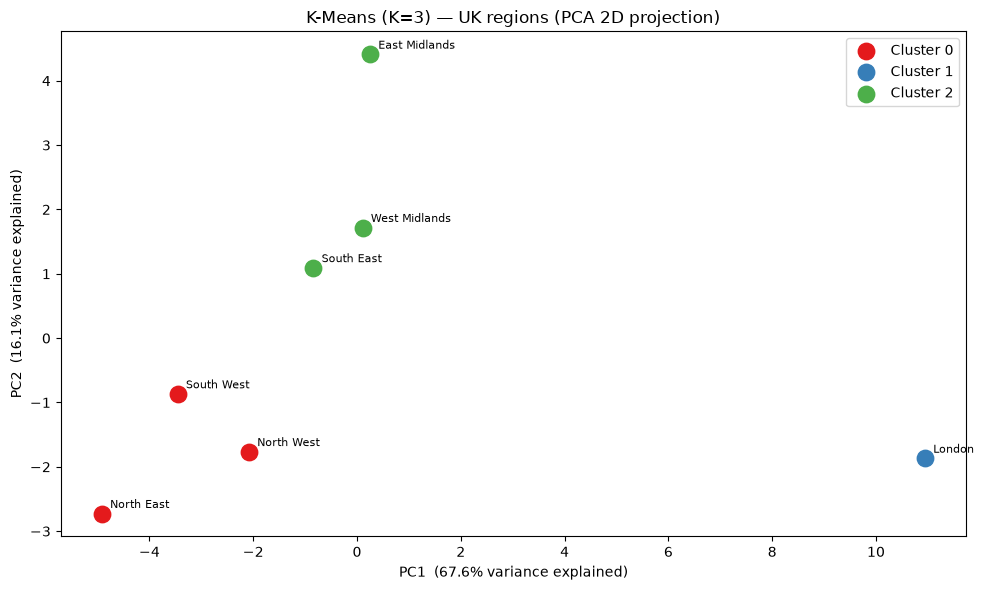

Cluster plot saved to kmeans_clusters.png

Cluster feature means:
         Pay_Resident  Pay_Workplace  Pay_Diff_Pct  Rental_Index
Cluster                                                         
0             37455.6        37164.4          -0.8         122.6
1             46940.4        49826.4           6.1         121.2
2             39294.7        38306.7          -2.4         128.8


In [7]:
import pandas as pd
import numpy as np
from functools import reduce
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")


# ── 1. ASHE pay — most recent year, full-time median, weekly → annual ─────────
def load_ashe(path, pay_col):
    df = pd.read_csv(path)
    df = df[
        (df["MEASURES"] == 20100) &
        (df["SEX_NAME"] == "Full Time Workers") &
        (df["ITEM_NAME"] == "Median") &
        (df["PAY_NAME"] == "Weekly pay - gross")
    ]
    latest = df["DATE"].max()
    df = df[df["DATE"] == latest][["GEOGRAPHY_NAME", "OBS_VALUE"]].copy()
    df.columns = ["Region", pay_col]
    df[pay_col] = pd.to_numeric(df[pay_col], errors="coerce") * 52
    return df.groupby("Region")[pay_col].mean().reset_index()


df_resident  = load_ashe("data/nomis_ashe_resident.csv",  "Pay_Resident")
df_workplace = load_ashe("data/nomis_ashe_workplace.csv", "Pay_Workplace")
df_pay = pd.merge(df_resident, df_workplace, on="Region")
df_pay["Pay_Diff_Pct"] = (
    (df_pay["Pay_Workplace"] - df_pay["Pay_Resident"]) / df_pay["Pay_Resident"] * 100
)


# ── 2. Rental price index — most recent index value per English region ────────
REGION_CODE_MAP = {
    "E12000001": "North East",
    "E12000002": "North West",
    "E12000003": "Yorkshire and The Humber",
    "E12000004": "East Midlands",
    "E12000005": "West Midlands",
    "E12000006": "East of England",
    "E12000007": "London",
    "E12000008": "South East",
    "E12000009": "South West",
}

df_rental = pd.read_csv("data/ons_index_private_housing_rental_prices.csv")
df_rental = df_rental[
    (df_rental["IndexAndYearChange"] == "Index") &
    (df_rental["administrative-geography"].isin(REGION_CODE_MAP))
].copy()
df_rental["Region"] = df_rental["administrative-geography"].map(REGION_CODE_MAP)
df_rental["Date"] = pd.to_datetime(df_rental["mmm-yy"], format="%b-%y")
df_rental = (
    df_rental.sort_values("Date")
    .groupby("Region")
    .last()[["v4_1"]]
    .reset_index()
    .rename(columns={"v4_1": "Rental_Index"})
)
df_rental["Rental_Index"] = pd.to_numeric(df_rental["Rental_Index"], errors="coerce")


# ── 3. Demographic features — aggregate local authority data to region ────────
loc_map = pd.read_csv("data/location_mapping.csv")
loc_map.columns = ["Local_area", "Region"]


def pivot_to_region_proportions(path, cat_col, area_col="Lower tier local authorities",
                                region_col=None, prefix=None):
    """Load a long-format census file, aggregate to region, pivot and normalise."""
    df = pd.read_csv(path)
    df = df[~df[cat_col].astype(str).str.startswith("Does not apply")]

    if region_col and region_col in df.columns:
        df = df.rename(columns={region_col: "Region"})
    else:
        df = df.merge(loc_map, left_on=area_col, right_on="Local_area", how="left")
        df = df.dropna(subset=["Region"])

    df_agg = df.groupby(["Region", cat_col])["Observation"].sum().reset_index()
    df_pivot = df_agg.pivot_table(index="Region", columns=cat_col,
                                  values="Observation", fill_value=0)
    df_pivot = df_pivot.div(df_pivot.sum(axis=1), axis=0)  # proportions

    short = prefix or cat_col.split("(")[0].strip().lower().replace(" ", "_")
    df_pivot.columns = [f"{short}_{c}" for c in df_pivot.columns]
    return df_pivot.reset_index()


df_religion = pivot_to_region_proportions(
    "data/religion_with_region.csv",
    cat_col="Religion (10 categories)",
    region_col="geography",
    prefix="rel",
)
df_sex = pivot_to_region_proportions(
    "data/sex_with_region.csv",
    cat_col="Sex (2 categories)",
    prefix="sex",
)
df_ethnic = pivot_to_region_proportions(
    "data/ethnicity_with_region.csv",
    cat_col="Ethnic group (20 categories)",
    prefix="eth",
)


# ── 4. Merge all datasets on Region ──────────────────────────────────────────
dfs = [df_pay, df_rental, df_religion, df_sex, df_ethnic]
df_all = reduce(lambda l, r: pd.merge(l, r, on="Region", how="inner"), dfs)
df_all = df_all.dropna().reset_index(drop=True)

print(f"Regions used for clustering: {len(df_all)}")
print(df_all["Region"].tolist())


# ── 5. Scale features ─────────────────────────────────────────────────────────
regions  = df_all["Region"].copy()
features = df_all.drop(columns="Region")

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(features)


# ── 6. Elbow method — find the best k ────────────────────────────────────────
k_range = range(2, min(8, len(df_all)))  
inertia = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow method — choose k where the curve bends")
plt.tight_layout()
plt.savefig("elbow_plot.png", dpi=150)
plt.show()
print("Elbow plot saved to elbow_plot.png")


# ── 7. Fit K-Means — adjust K after inspecting the elbow plot ────────────────
K = 3   # <-- change this after looking at the elbow plot

km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df_all["Cluster"] = km_final.fit_predict(X_scaled)

print(f"\nK-Means (K={K}) — Region assignments:")
display_cols = ["Region", "Cluster", "Pay_Resident", "Pay_Workplace",
                "Pay_Diff_Pct", "Rental_Index"]
print(df_all[display_cols].sort_values("Cluster").to_string(index=False))


# ── 8. PCA scatter — visualise clusters in 2D ────────────────────────────────
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

colours = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]
plt.figure(figsize=(10, 6))
for c in sorted(df_all["Cluster"].unique()):
    mask = df_all["Cluster"] == c
    plt.scatter(coords[mask, 0], coords[mask, 1],
                color=colours[c % len(colours)],
                label=f"Cluster {c}", s=140, zorder=3)
    for i in df_all[mask].index:
        plt.annotate(regions.iloc[i], (coords[i, 0], coords[i, 1]),
                     textcoords="offset points", xytext=(6, 4), fontsize=8)

plt.xlabel(f"PC1  ({pca.explained_variance_ratio_[0]:.1%} variance explained)")
plt.ylabel(f"PC2  ({pca.explained_variance_ratio_[1]:.1%} variance explained)")
plt.title(f"K-Means (K={K}) — UK regions (PCA 2D projection)")
plt.legend()
plt.tight_layout()
plt.savefig("kmeans_clusters.png", dpi=150)
plt.show()
print("Cluster plot saved to kmeans_clusters.png")


# ── 9. Cluster summary ────────────────────────────────────────────────────────
summary = df_all.groupby("Cluster")[
    ["Pay_Resident", "Pay_Workplace", "Pay_Diff_Pct", "Rental_Index"]
].mean().round(1)
print("\nCluster feature means:")
print(summary)





Cities used for clustering: 33
                    City                   Region
                barnsley Yorkshire and The Humber
   blackburn with darwen               North West
               blackpool               North West
                  bolton               North West
                    bury               North West
              darlington               North East
               doncaster Yorkshire and The Humber
east riding of yorkshire Yorkshire and The Humber
                  halton               North West
              hartlepool               North East
                knowsley               North West
               liverpool               North West
              manchester               North West
           middlesbrough               North East
     newcastle upon tyne               North East


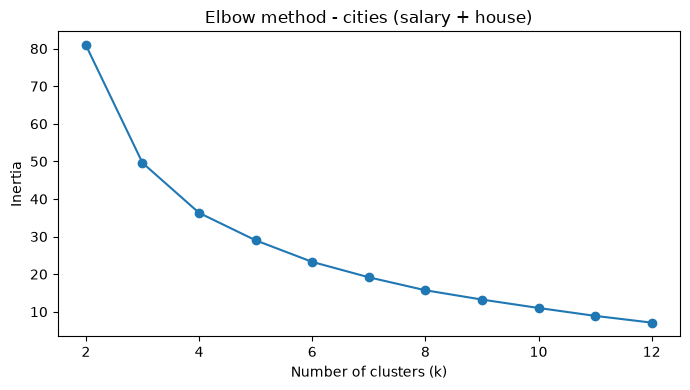

                    City                   Region  Cluster  Pay_Resident  Pay_Workplace  Pay_Diff_Pct  House_Price
                  halton               North West        0       19562.4        18631.6     -4.758107     158000.0
                knowsley               North West        0       18522.4        17643.6     -4.744526     159975.0
               liverpool               North West        0       19307.6        17524.0     -9.237813     150750.0
              manchester               North West        0       19723.6        18246.8     -7.487477     213000.0
      north lincolnshire Yorkshire and The Humber        0       21325.2        18657.6    -12.509144     160000.0
    redcar and cleveland               North East        0       19942.0        19110.0     -4.172099     140000.0
                 salford               North West        0       19089.2        17914.0     -6.156361     200000.0
        stockton on tees               North East        0       21538.4        

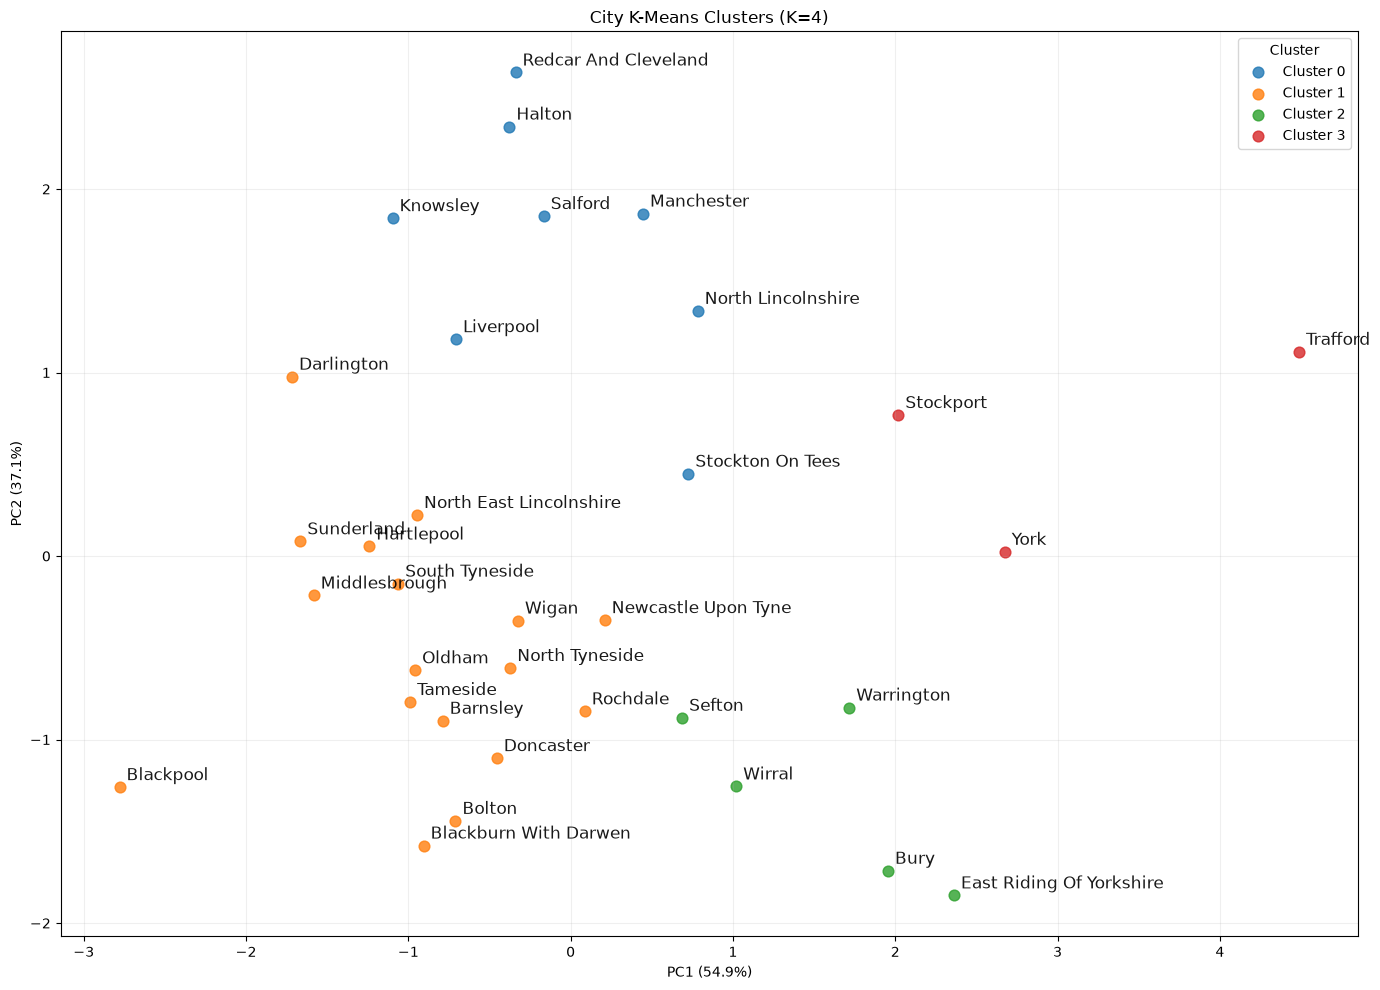

In [11]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


DATA_DIR = Path("data")


def normalize_name(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    value = value.replace("&", " and ")
    value = value.replace("-", " ")
    value = re.sub(r"\s+", " ", value)
    return value


def load_ashe_city(path, pay_col):
    df = pd.read_csv(path)
    df = df[
        (df["MEASURES"] == 20100)
        & (df["SEX_NAME"] == "Full Time Workers")
        & (df["ITEM_NAME"] == "Median")
        & (df["PAY_NAME"] == "Weekly pay - gross")
    ].copy()

    latest_year = df["DATE"].max()
    df = df[df["DATE"] == latest_year].copy()

    out = df[["GEOGRAPHY_NAME", "GEOGRAPHY_CODE_REGION", "OBS_VALUE"]].copy()
    out["City"] = out["GEOGRAPHY_NAME"].map(normalize_name)
    out["Region"] = out["GEOGRAPHY_CODE_REGION"].astype(str).str.strip()
    out[pay_col] = pd.to_numeric(out["OBS_VALUE"], errors="coerce") * 52
    out = out[["City", "Region", pay_col]].dropna(subset=["City", pay_col])

    return out.groupby(["City", "Region"], as_index=False)[pay_col].mean()


def load_house_prices_city_from_4_parts():
    part_files = [
        DATA_DIR / "ons_house_prices_local_authority.part001.csv",
        DATA_DIR / "ons_house_prices_local_authority.part002.csv",
        DATA_DIR / "ons_house_prices_local_authority.part003.csv",
        DATA_DIR / "ons_house_prices_local_authority.part004.csv",
    ]

    missing = [p.name for p in part_files if not p.exists()]
    if missing:
        raise FileNotFoundError(
            f"Missing house price part files: {missing}. Expected part001-part004 in data/."
        )

    frames = [pd.read_csv(p) for p in part_files]
    hp = pd.concat(frames, ignore_index=True)

    hp = hp[
        (hp["house-sales-and-prices"] == "median")
        & (hp["property-type"] == "all")
        & (hp["build-status"] == "all")
    ].copy()

    hp["House_Price"] = pd.to_numeric(hp["V4_1"], errors="coerce")
    hp["Date"] = pd.to_datetime(
        hp["mmm"].astype(str).str.title() + "-" + hp["calendar-years"].astype(str),
        format="%b-%Y",
        errors="coerce",
    )
    hp["Date"] = hp["Date"].fillna(pd.to_datetime(hp["Time"], errors="coerce"))

    hp = hp.dropna(subset=["House_Price", "Date", "Geography"])
    hp = hp.sort_values("Date").groupby("Geography", as_index=False).last()

    hp["City"] = hp["Geography"].map(normalize_name)
    return hp[["City", "House_Price"]]


# 1) Salary
df_resident = load_ashe_city(DATA_DIR / "nomis_ashe_resident_cities.csv", "Pay_Resident")
df_workplace = load_ashe_city(DATA_DIR / "nomis_ashe_workplace_cities.csv", "Pay_Workplace")

df_pay = pd.merge(df_resident, df_workplace, on=["City", "Region"], how="inner")
df_pay["Pay_Diff_Pct"] = (
    (df_pay["Pay_Workplace"] - df_pay["Pay_Resident"]) / df_pay["Pay_Resident"] * 100
)

# 2) House prices from 4 ONS part files
df_house = load_house_prices_city_from_4_parts()

# 3) Merge final features (salary + house only)
df_all = (
    df_pay
    .merge(df_house, on="City", how="inner")
    .dropna()
    .reset_index(drop=True)
)

print(f"Cities used for clustering: {len(df_all)}")
if len(df_all) < 3:
    raise ValueError("Too few matched cities after merging salary + house prices.")
print(df_all[["City", "Region"]].head(15).to_string(index=False))

# 4) Scale features
feature_cols = ["Pay_Resident", "Pay_Workplace", "Pay_Diff_Pct", "House_Price"]
X = df_all[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5) Elbow method
k_max = min(12, len(df_all) - 1)
k_range = range(2, k_max + 1)
inertia = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow method - cities (salary + house)")
plt.tight_layout()
plt.show()

# 6) Final KMeans
K = 4  # adjust after elbow
km_final = KMeans(n_clusters=K, random_state=42, n_init=20)
df_all["Cluster"] = km_final.fit_predict(X_scaled)

print(
    df_all[
        ["City", "Region", "Cluster", "Pay_Resident", "Pay_Workplace", "Pay_Diff_Pct", "House_Price"]
    ]
    .sort_values(["Cluster", "City"])
    .to_string(index=False)
)

# 7) PCA plot with city labels
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(14, 10))

for cid in sorted(df_all["Cluster"].unique()):
    m = df_all["Cluster"] == cid

    plt.scatter(
        coords[m, 0],
        coords[m, 1],
        s=60,
        label=f"Cluster {cid}",
        alpha=0.8
    )

    # Add city labels
    for i in df_all.index[m]:
        plt.annotate(
            df_all.loc[i, "City"].title(),
            (coords[i, 0], coords[i, 1]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=12,
            alpha=0.9
        )

plt.title(f"City K-Means Clusters (K={K})")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.legend(title="Cluster")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [12]:
# 8) PCA loadings: understand what PC1 and PC2 represent

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=["PC1", "PC2"]
)

print("\nPCA Loadings:")
print(loadings.round(3).to_string())

# Explained variance
print("\nExplained variance:")
print(
    pd.Series(
        pca.explained_variance_ratio_,
        index=["PC1", "PC2"]
    ).round(3)
)

# Contribution of each variable to each component
contribution = loadings ** 2

print("\nVariable contributions to PC1 and PC2:")
print(contribution.round(3).to_string())


PCA Loadings:
                 PC1    PC2
Pay_Resident   0.645 -0.096
Pay_Workplace  0.363  0.675
Pay_Diff_Pct  -0.304  0.729
House_Price    0.600  0.064

Explained variance:
PC1    0.549
PC2    0.371
dtype: float64

Variable contributions to PC1 and PC2:
                 PC1    PC2
Pay_Resident   0.416  0.009
Pay_Workplace  0.132  0.456
Pay_Diff_Pct   0.092  0.531
House_Price    0.360  0.004


Cities used for clustering: 46
Regions represented: 2


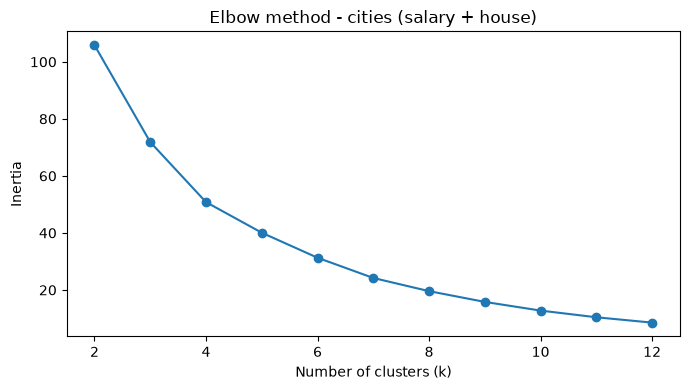


Cluster sizes:
Cluster
0    12
1    10
2     1
3    23

Cluster assignments (sample):
             City  Region  Cluster
       birmingham England        0
          cardiff   Wales        0
         coventry England        0
            derby England        0
           exeter England        0
       manchester England        0
    milton keynes England        0
           oxford England        0
       portsmouth England        0
      southampton England        0
        worcester England        0
             york England        0
brighton and hove England        1
        cambridge England        1
       canterbury England        1
       chelmsford England        1
       chichester England        1
       colchester England        1
        lichfield England        1
  southend on sea England        1
        st albans England        1
       winchester England        1
      westminster England        2
         bradford England        3
        doncaster England        3
   

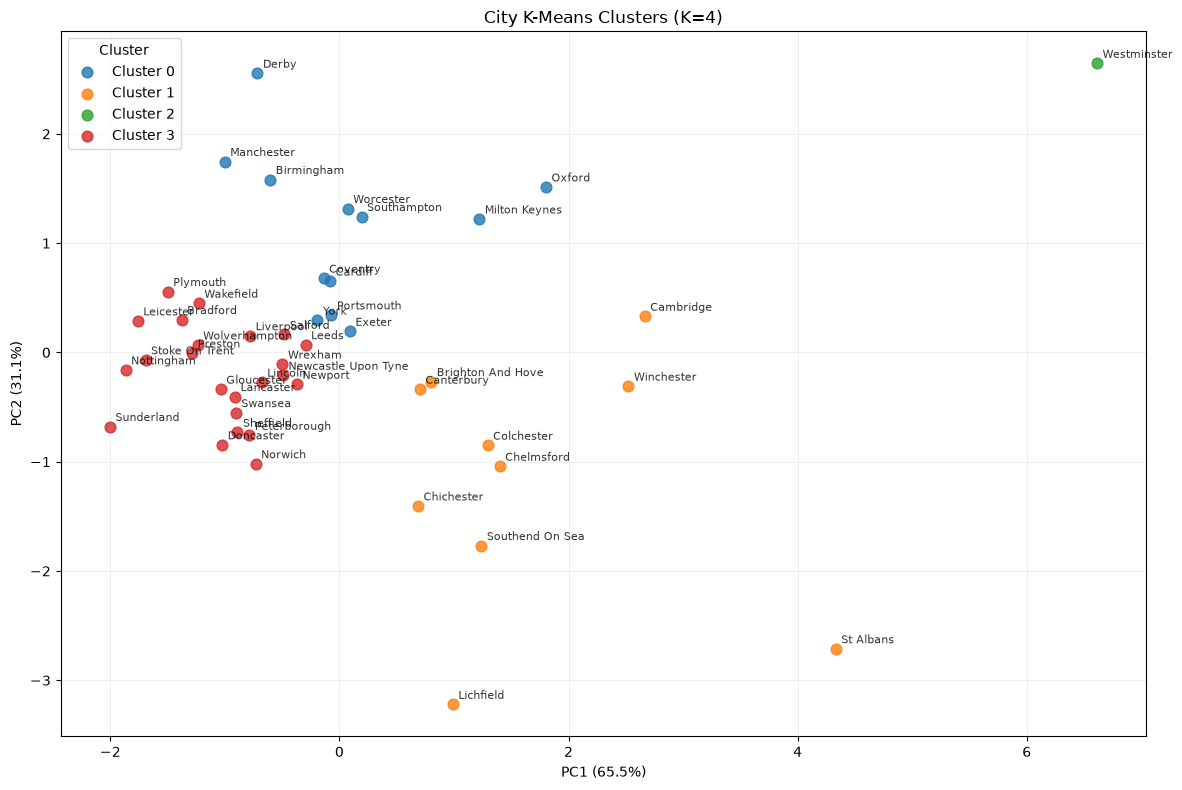


PCA explained variance ratio: [0.655 0.311]


In [28]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# New, self-contained replication cell that uses the current data folder structure.
ROOT = Path("..") / "data"
NOMIS_DIR = ROOT / "nomis_data"
ONS_DIR = ROOT / "ons_data"


def normalize_name(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    value = value.replace("&", " and ")
    value = value.replace("-", " ")
    value = re.sub(r"\s+", " ", value)
    return value


def load_ashe_city(path, pay_col):
    df = pd.read_csv(path, low_memory=False)

    measures_col = "MEASURES" if "MEASURES" in df.columns else "MEASURES_NAME"
    df = df[
        (df[measures_col].astype(str).isin(["20100", "Value"]))
        & (df["SEX_NAME"].astype(str) == "Full Time Workers")
        & (df["ITEM_NAME"].astype(str) == "Median")
        & (df["PAY_NAME"].astype(str) == "Weekly pay - gross")
    ].copy()

    latest_year = pd.to_numeric(df["DATE"], errors="coerce").max()
    df = df[pd.to_numeric(df["DATE"], errors="coerce") == latest_year].copy()

    if "GEOGRAPHY_CODE_REGION" in df.columns:
        region = df["GEOGRAPHY_CODE_REGION"].astype(str).str.strip()
    else:
        code = df["GEOGRAPHY_CODE"].astype(str).str.strip().str[0]
        region = code.map({"E": "England", "W": "Wales", "S": "Scotland", "N": "Northern Ireland"})

    out = df[["GEOGRAPHY_NAME", "OBS_VALUE"]].copy()
    out["City"] = out["GEOGRAPHY_NAME"].map(normalize_name)
    out["Region"] = region
    out[pay_col] = pd.to_numeric(out["OBS_VALUE"], errors="coerce") * 52
    out = out[["City", "Region", pay_col]].dropna(subset=["City", "Region", pay_col])

    return out.groupby(["City", "Region"], as_index=False)[pay_col].mean()


def load_house_prices_city():
    part_files = sorted(ONS_DIR.glob("ons_house_prices_local_authority.part*.csv"))
    if not part_files:
        raise FileNotFoundError("No house price part files found under data/ons_data")

    hp = pd.concat([pd.read_csv(path, low_memory=False) for path in part_files], ignore_index=True)

    hp = hp[
        (hp["house-sales-and-prices"].astype(str).str.lower() == "median")
        & (hp["property-type"].astype(str).str.lower() == "all")
        & (hp["build-status"].astype(str).str.lower() == "all")
    ].copy()

    hp["House_Price"] = pd.to_numeric(hp["V4_1"], errors="coerce")
    hp["Date"] = pd.to_datetime(
        hp["mmm"].astype(str).str.title() + "-" + hp["calendar-years"].astype(str),
        format="%b-%Y",
        errors="coerce",
    )

    hp = hp.dropna(subset=["House_Price", "Date", "Geography"]).copy()
    hp = hp.sort_values("Date").groupby("Geography", as_index=False).last()
    hp["City"] = hp["Geography"].map(normalize_name)

    return hp[["City", "House_Price"]]


# 1) Load latest city pay features.
df_resident_city = load_ashe_city(NOMIS_DIR / "nomis_ashe_resident_cities.csv", "Pay_Resident")
df_workplace_city = load_ashe_city(NOMIS_DIR / "nomis_ashe_workplace_cities.csv", "Pay_Workplace")

df_pay_city = pd.merge(df_resident_city, df_workplace_city, on=["City", "Region"], how="inner")
df_pay_city["Pay_Diff_Pct"] = (
    (df_pay_city["Pay_Workplace"] - df_pay_city["Pay_Resident"]) / df_pay_city["Pay_Resident"] * 100
)

# 2) Load latest city house prices.
df_house_city = load_house_prices_city()

# 3) Merge into final feature matrix.
df_city = df_pay_city.merge(df_house_city, on="City", how="inner").dropna().reset_index(drop=True)

print(f"Cities used for clustering: {len(df_city)}")
print(f"Regions represented: {df_city['Region'].nunique()}")

if len(df_city) < 3:
    raise ValueError("Need at least 3 rows to run this K-means setup.")

feature_cols = ["Pay_Resident", "Pay_Workplace", "Pay_Diff_Pct", "House_Price"]
X = df_city[feature_cols].copy()

# 4) Scale features before K-means.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5) Elbow plot for k selection.
k_max = min(12, len(df_city) - 1)
k_range = range(2, k_max + 1)
inertia = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow method - cities (salary + house)")
plt.tight_layout()
plt.show()

# 6) Final K-means (adjust K after reviewing elbow curve).
K = 4
km_final_city = KMeans(n_clusters=K, random_state=42, n_init=20)
df_city["Cluster"] = km_final_city.fit_predict(X_scaled)

print("\nCluster sizes:")
print(df_city["Cluster"].value_counts().sort_index().to_string())

print("\nCluster assignments (sample):")
print(df_city[["City", "Region", "Cluster"]].sort_values(["Cluster", "City"]).head(30).to_string(index=False))

summary_city = df_city.groupby("Cluster")[feature_cols].mean().round(1)
print("\nCluster feature means:")
print(summary_city.to_string())

# 7) PCA visualization with city labels.
pca_city = PCA(n_components=2, random_state=42)
coords_city = pca_city.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
for cid in sorted(df_city["Cluster"].unique()):
    mask = df_city["Cluster"] == cid
    plt.scatter(coords_city[mask, 0], coords_city[mask, 1], s=60, label=f"Cluster {cid}", alpha=0.8)

for idx, row in df_city.reset_index(drop=True).iterrows():
    plt.annotate(
        row["City"].title(),
        (coords_city[idx, 0], coords_city[idx, 1]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
        alpha=0.8,
    )

plt.title(f"City K-Means Clusters (K={K})")
plt.xlabel(f"PC1 ({pca_city.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca_city.explained_variance_ratio_[1]:.1%})")
plt.legend(title="Cluster")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("\nPCA explained variance ratio:", np.round(pca_city.explained_variance_ratio_, 3))

### Coverage-improved city clustering (new)

This new section keeps all existing cells unchanged and runs an alternative pipeline to improve city coverage.

What it changes:
- Uses `../data/city_house_prices_latest.csv` for house prices (city-level curated file).
- Applies explicit alias mapping (for known city-name variants).
- Keeps strict data quality rules for missing pay values.

What it does **not** change:
- It does not edit or overwrite your original clustering cells/results.

Cities used (coverage-improved): 59
Regions represented: 2
London present: True


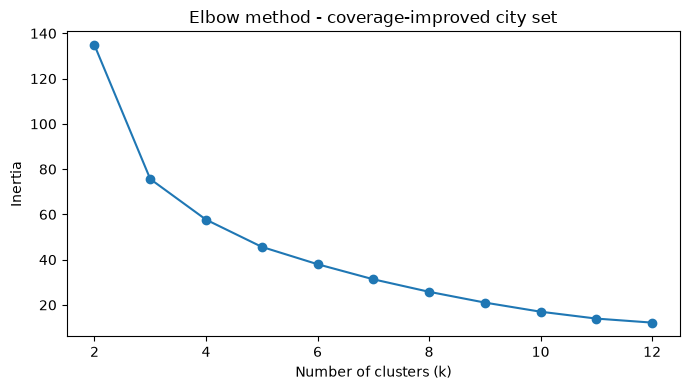


Cluster sizes (coverage-improved):
Cluster
0    14
1    30
2     2
3    13

Sample assignments:
               City  Region  Cluster
               bath England        0
  brighton and hove England        0
          cambridge England        0
         canterbury England        0
         chelmsford England        0
            chester England        0
         chichester England        0
         colchester England        0
                ely England        0
          lichfield England        0
          salisbury England        0
    southend on sea England        0
          st albans England        0
         winchester England        0
             bangor   Wales        1
           bradford England        1
          doncaster England        1
             durham England        1
         gloucester England        1
           hereford England        1
 kingston upon hull England        1
          lancaster England        1
              leeds England        1
          leice

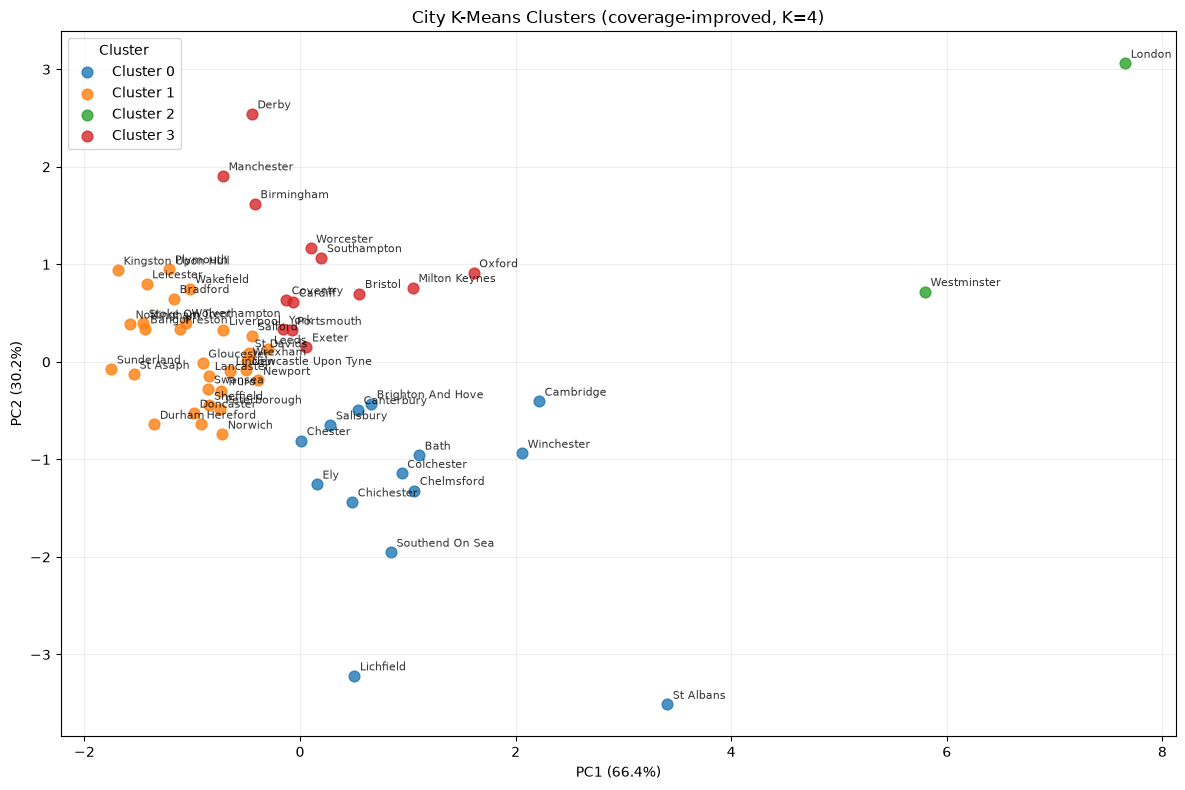


PCA explained variance ratio: [0.664 0.302]


In [29]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

ROOT = Path("..") / "data"
NOMIS_DIR = ROOT / "nomis_data"


def normalize_name(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    value = value.replace("&", " and ")
    value = value.replace("-", " ")
    value = re.sub(r"\s+", " ", value)
    return value


# Map known naming variants to a canonical city name used for matching.
CITY_ALIASES = {
    "city of london": "london",
    "city of westminster": "westminster",
    "kingston upon hull city of": "kingston upon hull",
    "bristol city of": "bristol",
    "bath and north east somerset": "bath",
    "herefordshire county of": "hereford",
    "cheshire west and chester": "chester",
    "durham county": "durham",
}


def canonical_city(value):
    name = normalize_name(value)
    if pd.isna(name):
        return np.nan
    return CITY_ALIASES.get(name, name)


def load_ashe_city(path, pay_col):
    df = pd.read_csv(path, low_memory=False)

    measures_col = "MEASURES" if "MEASURES" in df.columns else "MEASURES_NAME"
    df = df[
        (df[measures_col].astype(str).isin(["20100", "Value"]))
        & (df["SEX_NAME"].astype(str) == "Full Time Workers")
        & (df["ITEM_NAME"].astype(str) == "Median")
        & (df["PAY_NAME"].astype(str) == "Weekly pay - gross")
    ].copy()

    latest_year = pd.to_numeric(df["DATE"], errors="coerce").max()
    df = df[pd.to_numeric(df["DATE"], errors="coerce") == latest_year].copy()

    if "GEOGRAPHY_CODE_REGION" in df.columns:
        region = df["GEOGRAPHY_CODE_REGION"].astype(str).str.strip()
    else:
        code_prefix = df["GEOGRAPHY_CODE"].astype(str).str.strip().str[0]
        region = code_prefix.map({"E": "England", "W": "Wales", "S": "Scotland", "N": "Northern Ireland"})

    out = df[["GEOGRAPHY_NAME", "OBS_VALUE"]].copy()
    out["City"] = out["GEOGRAPHY_NAME"].map(canonical_city)
    out["Region"] = region
    out[pay_col] = pd.to_numeric(out["OBS_VALUE"], errors="coerce") * 52
    out = out[["City", "Region", pay_col]].dropna(subset=["City", "Region", pay_col])

    return out.groupby(["City", "Region"], as_index=False)[pay_col].mean()


def load_city_house_prices_latest(path):
    df = pd.read_csv(path, low_memory=False)

    value_col = "Median_Price" if "Median_Price" in df.columns else "Mean_Price"
    df["House_Price"] = pd.to_numeric(df[value_col], errors="coerce")
    df["City"] = df["City"].map(canonical_city)

    out = (
        df[["City", "House_Price"]]
        .dropna(subset=["City", "House_Price"])
        .groupby("City", as_index=False)["House_Price"]
        .mean()
    )
    return out


# 1) Pay features
resident = load_ashe_city(NOMIS_DIR / "nomis_ashe_resident_cities.csv", "Pay_Resident")
workplace = load_ashe_city(NOMIS_DIR / "nomis_ashe_workplace_cities.csv", "Pay_Workplace")
df_pay = resident.merge(workplace, on=["City", "Region"], how="inner")
df_pay["Pay_Diff_Pct"] = (
    (df_pay["Pay_Workplace"] - df_pay["Pay_Resident"]) / df_pay["Pay_Resident"] * 100
)

# 2) House features from curated city file
house = load_city_house_prices_latest(ROOT / "city_house_prices_latest.csv")

# 3) Merge
df_improved = df_pay.merge(house, on="City", how="inner").dropna().reset_index(drop=True)

print(f"Cities used (coverage-improved): {len(df_improved)}")
print(f"Regions represented: {df_improved['Region'].nunique()}")
print("London present:", "london" in set(df_improved["City"]))

if len(df_improved) < 3:
    raise ValueError("Need at least 3 rows to run K-means.")

feature_cols = ["Pay_Resident", "Pay_Workplace", "Pay_Diff_Pct", "House_Price"]
X = df_improved[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4) Elbow curve
k_max = min(12, len(df_improved) - 1)
k_range = range(2, k_max + 1)
inertia = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow method - coverage-improved city set")
plt.tight_layout()
plt.show()

# 5) Final model (adjust if needed)
K_IMPROVED = 4
km_final = KMeans(n_clusters=K_IMPROVED, random_state=42, n_init=20)
df_improved["Cluster"] = km_final.fit_predict(X_scaled)

print("\nCluster sizes (coverage-improved):")
print(df_improved["Cluster"].value_counts().sort_index().to_string())

print("\nSample assignments:")
print(
    df_improved[["City", "Region", "Cluster"]]
    .sort_values(["Cluster", "City"])
    .head(40)
    .to_string(index=False)
)

# 6) PCA plot
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
for cid in sorted(df_improved["Cluster"].unique()):
    m = df_improved["Cluster"] == cid
    plt.scatter(coords[m, 0], coords[m, 1], s=60, label=f"Cluster {cid}", alpha=0.8)

for i, row in df_improved.reset_index(drop=True).iterrows():
    plt.annotate(
        row["City"].title(),
        (coords[i, 0], coords[i, 1]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
        alpha=0.8,
    )

plt.title(f"City K-Means Clusters (coverage-improved, K={K_IMPROVED})")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.legend(title="Cluster")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("\nPCA explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))

In [30]:
# Explain PC1 and PC2 in plain English using feature loadings
import numpy as np
import pandas as pd


def _direction_text(sign):
    return "higher" if sign >= 0 else "lower"


def _top_features(components, feature_names, pc_index, top_n=3):
    s = pd.Series(components[pc_index], index=feature_names)
    top = s.reindex(s.abs().sort_values(ascending=False).index).head(top_n)
    return top


if "pca" not in globals() or "feature_cols" not in globals():
    raise RuntimeError("Run the clustering/PCA cell first so `pca` and `feature_cols` exist.")

if len(feature_cols) != pca.components_.shape[1]:
    raise RuntimeError("`feature_cols` does not match the fitted PCA components.")

explained = pca.explained_variance_ratio_
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=["PC1", "PC2"],
)

print("PCA loadings (weights):")
print(loadings.round(3).to_string())

print("\nExplained variance:")
print(pd.Series(explained[:2], index=["PC1", "PC2"]).round(3).to_string())

pc1_top = _top_features(pca.components_, feature_cols, 0, top_n=3)
pc2_top = _top_features(pca.components_, feature_cols, 1, top_n=3)

print("\nTop PC1 drivers:")
for f, w in pc1_top.items():
    print(f"- {f}: weight={w:.3f} ({_direction_text(w)} values push points to the right on PC1)")

print("\nTop PC2 drivers:")
for f, w in pc2_top.items():
    print(f"- {f}: weight={w:.3f} ({_direction_text(w)} values push points upward on PC2)")

pc1_human = ", ".join([f"{f} ({_direction_text(w)})" for f, w in pc1_top.items()])
pc2_human = ", ".join([f"{f} ({_direction_text(w)})" for f, w in pc2_top.items()])

print("\nHuman interpretation:")
print(
    f"- PC1 explains about {explained[0]:.1%} of variation. "
    f"It mainly reflects differences in: {pc1_human}."
)
print(
    f"- PC2 explains about {explained[1]:.1%} of variation. "
    f"It mainly reflects differences in: {pc2_human}."
)
print(
    "- On your PCA scatter: right/left movement is mostly PC1 effects, "
    "up/down movement is mostly PC2 effects. Cities close together have similar feature profiles."
)

PCA loadings (weights):
                 PC1    PC2
Pay_Resident   0.602 -0.105
Pay_Workplace  0.520  0.466
Pay_Diff_Pct  -0.158  0.876
House_Price    0.585 -0.069

Explained variance:
PC1    0.664
PC2    0.302

Top PC1 drivers:
- Pay_Resident: weight=0.602 (higher values push points to the right on PC1)
- House_Price: weight=0.585 (higher values push points to the right on PC1)
- Pay_Workplace: weight=0.520 (higher values push points to the right on PC1)

Top PC2 drivers:
- Pay_Diff_Pct: weight=0.876 (higher values push points upward on PC2)
- Pay_Workplace: weight=0.466 (higher values push points upward on PC2)
- Pay_Resident: weight=-0.105 (lower values push points upward on PC2)

Human interpretation:
- PC1 explains about 66.4% of variation. It mainly reflects differences in: Pay_Resident (higher), House_Price (higher), Pay_Workplace (higher).
- PC2 explains about 30.2% of variation. It mainly reflects differences in: Pay_Diff_Pct (higher), Pay_Workplace (higher), Pay_Resident (low

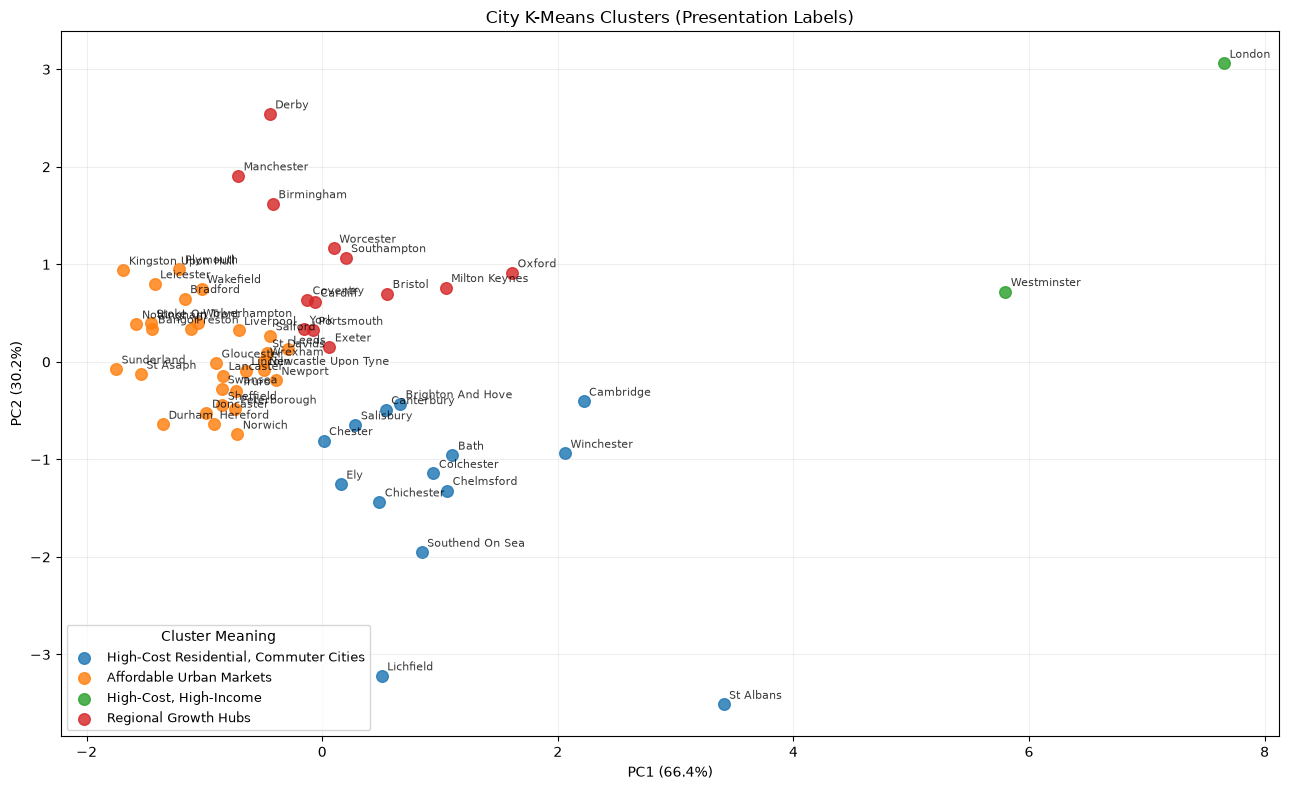

In [31]:
# Replot PCA with presentation-ready cluster labels
import matplotlib.pyplot as plt

if "df_improved" not in globals() or "coords" not in globals():
    raise RuntimeError("Run the coverage-improved clustering cell first so df_improved and coords exist.")

label_map = {
    2: "High-Cost, High-Income",
    0: "High-Cost Residential, Commuter Cities",
    3: "Regional Growth Hubs",
    1: "Affordable Urban Markets",
}

plt.figure(figsize=(13, 8))
for cid in sorted(df_improved["Cluster"].unique()):
    mask = df_improved["Cluster"] == cid
    legend_label = label_map.get(int(cid), f"Cluster {cid}")
    plt.scatter(coords[mask, 0], coords[mask, 1], s=70, alpha=0.82, label=legend_label)

for i, row in df_improved.reset_index(drop=True).iterrows():
    plt.annotate(
        row["City"].title(),
        (coords[i, 0], coords[i, 1]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
        alpha=0.78,
    )

if "pca" in globals() and hasattr(pca, "explained_variance_ratio_"):
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
else:
    plt.xlabel("PC1")
    plt.ylabel("PC2")

plt.title("City K-Means Clusters (Presentation Labels)")
plt.legend(title="Cluster Meaning", fontsize=9)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()